In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create graphs folder if it doesn't exist
os.makedirs('graphs', exist_ok=True)
print("Graphs folder created/verified")

In [38]:
df_YT = pd.read_csv("Youtube_samples_ANNOTATED.csv")
df_TK = pd.read_csv("TikTok_samples_ANNOTATED.csv")
df_IG = pd.read_csv("Instagram_samples_ANNOTATED.csv")
df_FB = pd.read_csv("Facebook_samples_ANNOTATED.csv")

In [39]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

# Add platform column to each dataframe
df_YT['platform'] = 'YouTube'
df_TK['platform'] = 'TikTok'
df_IG['platform'] = 'Instagram'
df_FB['platform'] = "Facebook"

# Combine all data for overall analysis
df_all = pd.concat([df_YT, df_TK, df_IG, df_FB], ignore_index=True)

# Define emotions
emotions = ['JOY', 'ANGER', 'SADNESS', 'SURPRISE', 'FEAR', 'NEUTRAL']

# When is_correct == 1, the actual_pillar is the same as model_prediction
# When is_correct == 0, actual_pillar contains the correction
df_all['actual_pillar'] = df_all['actual_pillar'].fillna(df_all['model_prediction'])

# Convert to string and remove any extra whitespace
df_all['actual_pillar'] = df_all['actual_pillar'].astype(str).str.strip().str.upper()
df_all['model_prediction'] = df_all['model_prediction'].astype(str).str.strip().str.upper()

print("Dataset Overview:")
print(f"Total samples: {len(df_all)}")
print(f"\nPlatform distribution:\n{df_all['platform'].value_counts()}")
print(f"\nAccuracy (is_correct==1): {(df_all['is_correct'].sum() / len(df_all) * 100):.2f}%")
print(f"\nUnique actual emotions: {sorted(df_all['actual_pillar'].unique())}")
print(f"Unique predicted emotions: {sorted(df_all['model_prediction'].unique())}")

Dataset Overview:
Total samples: 915

Platform distribution:
platform
Facebook     249
Instagram    225
TikTok       222
YouTube      219
Name: count, dtype: int64

Accuracy (is_correct==1): 75.85%

Unique actual emotions: ['ANGER', 'FEAR', 'JOY', 'NEUTRAL', 'SADNESS', 'SURPRISE']
Unique predicted emotions: ['ANGER', 'FEAR', 'JOY', 'NEUTRAL', 'SADNESS', 'SURPRISE']


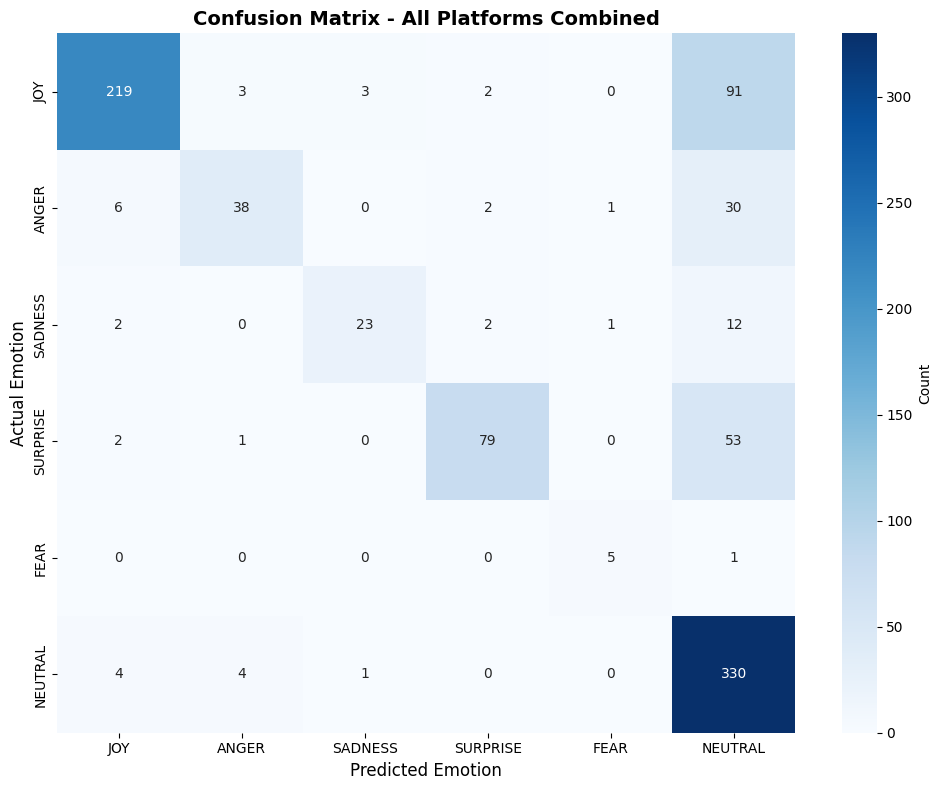

Confusion Matrix Summary:
Total predictions: 915
Correct predictions: 694
Overall Accuracy: 75.85%


In [ ]:
# 1. CONFUSION MATRIX - Overall
plt.figure(figsize=(10, 8))

# Create confusion matrix
y_true = df_all['actual_pillar']
y_pred = df_all['model_prediction']

cm = confusion_matrix(y_true, y_pred, labels=emotions)

# Plot
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotions, yticklabels=emotions,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - All Platforms Combined', fontsize=14, fontweight='bold')
plt.ylabel('Actual Emotion', fontsize=12)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.tight_layout()
plt.savefig('graphs/01_confusion_matrix_overall.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion Matrix Summary:")
print(f"Total predictions: {cm.sum()}")
print(f"Correct predictions: {np.trace(cm)}")
print(f"Overall Accuracy: {np.trace(cm) / cm.sum() * 100:.2f}%")

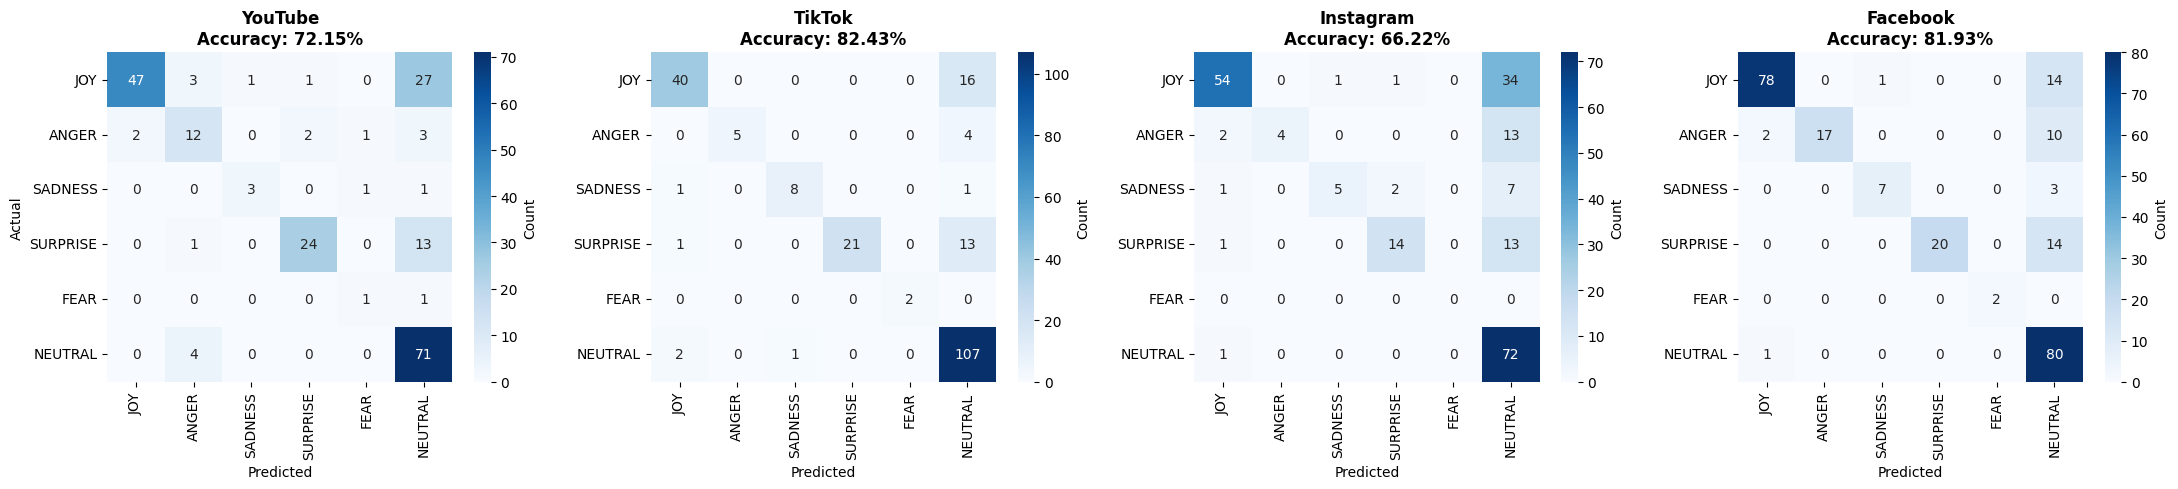


Per-Platform Accuracy:
YouTube: 72.15% (158/219)
TikTok: 82.43% (183/222)
Instagram: 66.22% (149/225)
Facebook: 81.93% (204/249)


In [ ]:
# 2. CONFUSION MATRICES - Per Platform
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
platforms_list = [('YouTube', df_all[df_all['platform'] == 'YouTube']), 
                   ('TikTok', df_all[df_all['platform'] == 'TikTok']), 
                   ('Instagram', df_all[df_all['platform'] == 'Instagram']),
                   ('Facebook', df_all[df_all['platform'] == 'Facebook'])]

for idx, (platform_name, df) in enumerate(platforms_list):
    y_true_platform = df['actual_pillar']
    y_pred_platform = df['model_prediction']
    cm = confusion_matrix(y_true_platform, y_pred_platform, labels=emotions)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=emotions, yticklabels=emotions,
                ax=axes[idx], cbar_kws={'label': 'Count'})
    
    accuracy = np.trace(cm) / cm.sum() * 100
    axes[idx].set_title(f'{platform_name}\nAccuracy: {accuracy:.2f}%', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual' if idx == 0 else '')
    axes[idx].set_xlabel('Predicted', fontsize=10)

plt.tight_layout()
plt.savefig('graphs/02_confusion_matrices_per_platform.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPer-Platform Accuracy:")
for platform_name, df in platforms_list:
    acc = (df['is_correct'].sum() / len(df) * 100)
    print(f"{platform_name}: {acc:.2f}% ({df['is_correct'].sum()}/{len(df)})")

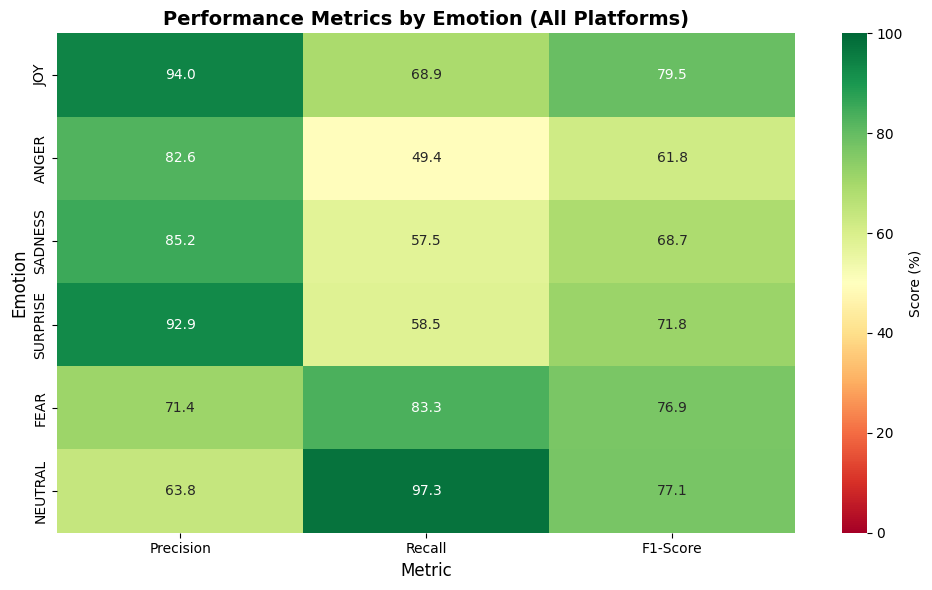


Detailed Performance Metrics:
          Precision  Recall  F1-Score
JOY           93.99   68.87     79.49
ANGER         82.61   49.35     61.79
SADNESS       85.19   57.50     68.66
SURPRISE      92.94   58.52     71.82
FEAR          71.43   83.33     76.92
NEUTRAL       63.83   97.35     77.10


In [ ]:
# 3. PERFORMANCE METRICS HEATMAP - Per Emotion
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics for each emotion
metrics_data = []
for emotion in emotions:
    y_true_binary = (y_true == emotion).astype(int)
    y_pred_binary = (y_pred == emotion).astype(int)
    
    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0) * 100
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0) * 100
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0) * 100
    metrics_data.append([precision, recall, f1])

metrics_df = pd.DataFrame(metrics_data, index=emotions, columns=['Precision', 'Recall', 'F1-Score'])

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df, annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': 'Score (%)'})
plt.title('Performance Metrics by Emotion (All Platforms)', fontsize=14, fontweight='bold')
plt.ylabel('Emotion', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.tight_layout()
plt.savefig('graphs/03_performance_metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDetailed Performance Metrics:")
print(metrics_df.round(2))

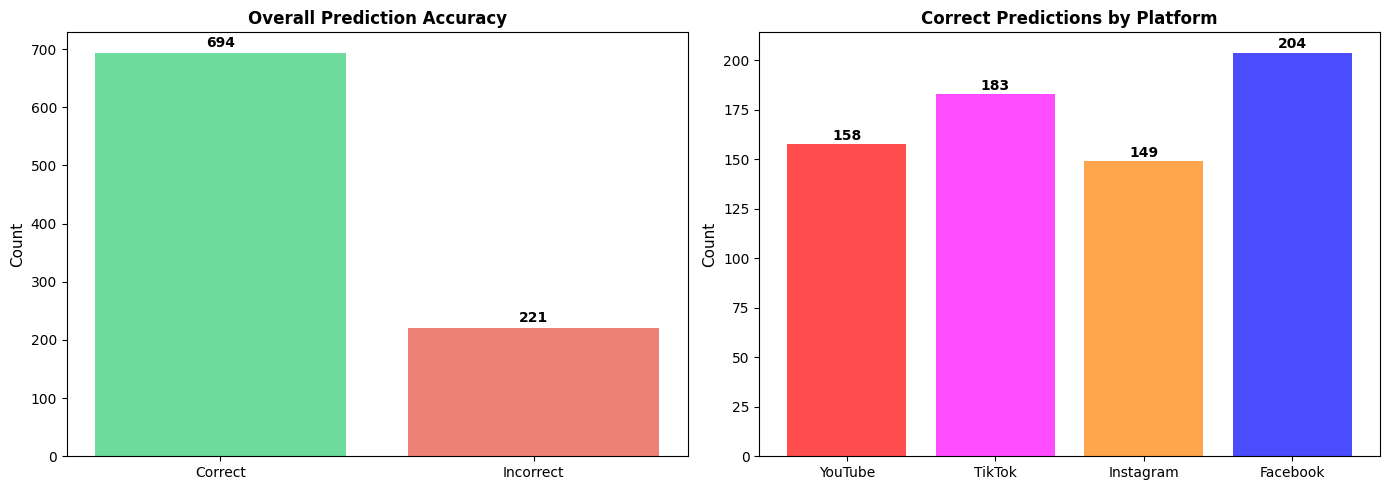

In [ ]:
# 4. ACCURACY BREAKDOWN - Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall accuracy
overall_correct = df_all['is_correct'].sum()
overall_incorrect = len(df_all) - overall_correct
axes[0].bar(['Correct', 'Incorrect'], [overall_correct, overall_incorrect], 
            color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[0].set_title('Overall Prediction Accuracy', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
for i, v in enumerate([overall_correct, overall_incorrect]):
    axes[0].text(i, v + len(df_all)*0.01, str(v), ha='center', fontweight='bold')

# Per-platform accuracy
platforms = []
correct_counts = []
for platform_name, df in platforms_list:
    platforms.append(platform_name)
    correct_counts.append(df['is_correct'].sum())

axes[1].bar(platforms, correct_counts, color=['#ff0000', '#ff00ff', '#ff8000', '#0000ff'], alpha=0.7)
axes[1].set_title('Correct Predictions by Platform', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11)
for i, v in enumerate(correct_counts):
    axes[1].text(i, v + max(correct_counts)*0.01, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/04_accuracy_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

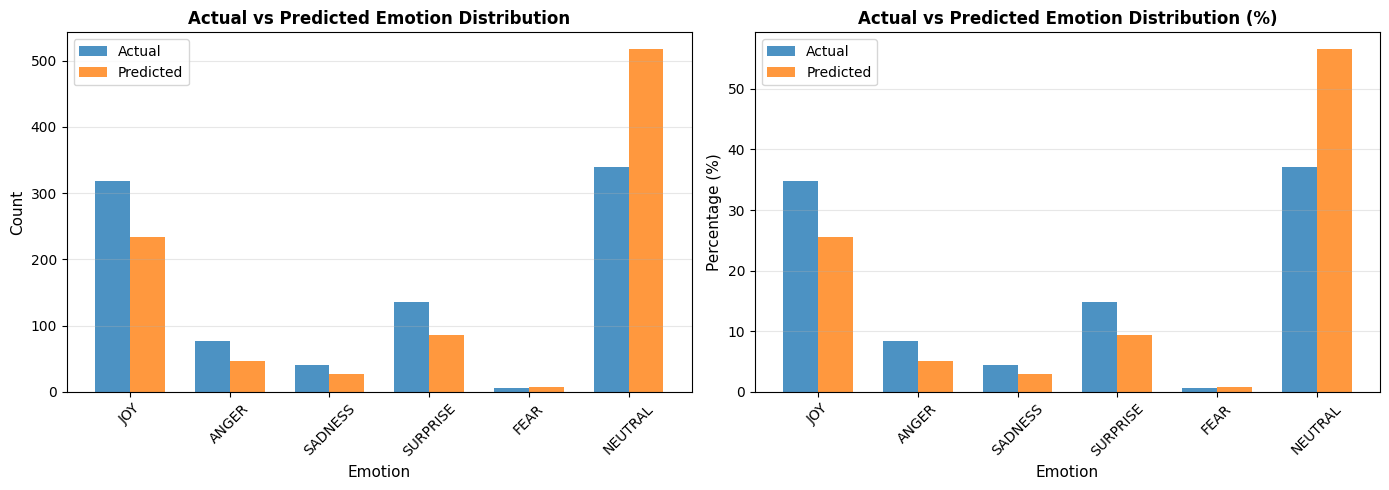

In [ ]:
# 5. EMOTION DISTRIBUTION - Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

actual_dist = df_all['actual_pillar'].value_counts().reindex(emotions, fill_value=0)
pred_dist = df_all['model_prediction'].value_counts().reindex(emotions, fill_value=0)

x = np.arange(len(emotions))
width = 0.35

axes[0].bar(x - width/2, actual_dist.values, width, label='Actual', alpha=0.8)
axes[0].bar(x + width/2, pred_dist.values, width, label='Predicted', alpha=0.8)
axes[0].set_xlabel('Emotion', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Actual vs Predicted Emotion Distribution', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(emotions, rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Distribution percentage
actual_pct = (actual_dist / actual_dist.sum() * 100)
pred_pct = (pred_dist / pred_dist.sum() * 100)

axes[1].bar(x - width/2, actual_pct.values, width, label='Actual', alpha=0.8)
axes[1].bar(x + width/2, pred_pct.values, width, label='Predicted', alpha=0.8)
axes[1].set_xlabel('Emotion', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].set_title('Actual vs Predicted Emotion Distribution (%)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(emotions, rotation=45)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/05_emotion_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

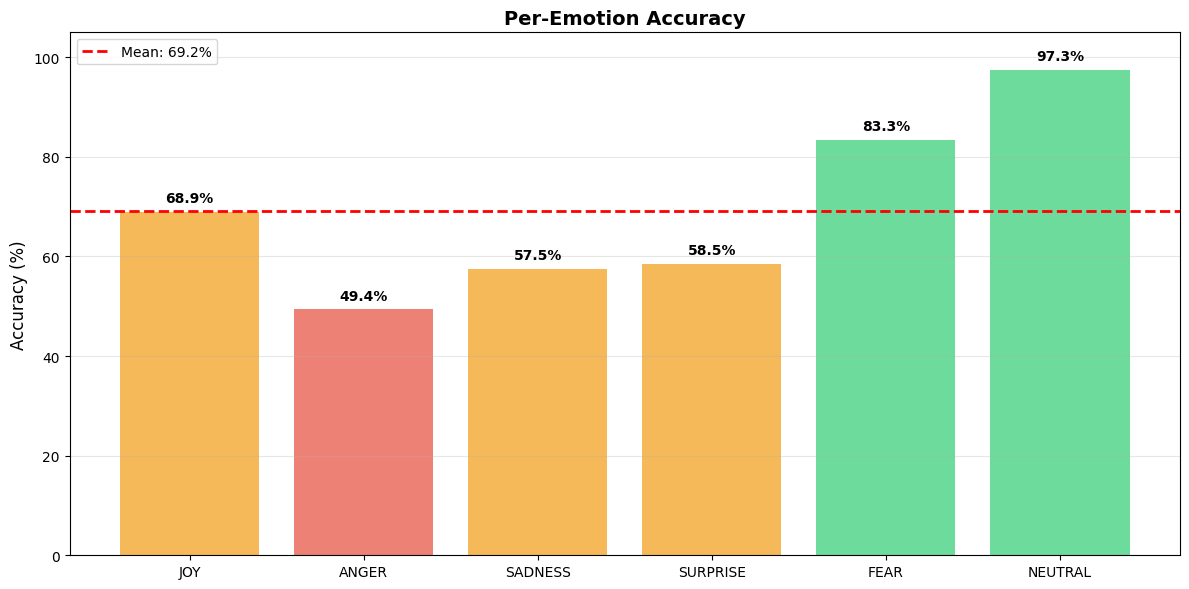


Per-Emotion Accuracy:
JOY: 68.87%
ANGER: 49.35%
SADNESS: 57.50%
SURPRISE: 58.52%
FEAR: 83.33%
NEUTRAL: 97.35%


In [ ]:
# 6. ERROR ANALYSIS - Accuracy per Emotion
accuracy_per_emotion = []
for emotion in emotions:
    mask = df_all['actual_pillar'] == emotion
    if mask.sum() > 0:
        acc = (df_all[mask]['is_correct'].sum() / mask.sum() * 100)
        accuracy_per_emotion.append(acc)
    else:
        accuracy_per_emotion.append(0)

colors = ['#2ecc71' if acc >= 70 else '#f39c12' if acc >= 50 else '#e74c3c' for acc in accuracy_per_emotion]

plt.figure(figsize=(12, 6))
bars = plt.bar(emotions, accuracy_per_emotion, color=colors, alpha=0.7)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Per-Emotion Accuracy', fontsize=14, fontweight='bold')
plt.ylim([0, 105])
plt.axhline(y=np.mean(accuracy_per_emotion), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(accuracy_per_emotion):.1f}%')

for i, (emotion, acc) in enumerate(zip(emotions, accuracy_per_emotion)):
    plt.text(i, acc + 2, f'{acc:.1f}%', ha='center', fontweight='bold')

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/06_per_emotion_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPer-Emotion Accuracy:")
for emotion, acc in zip(emotions, accuracy_per_emotion):
    print(f"{emotion}: {acc:.2f}%")

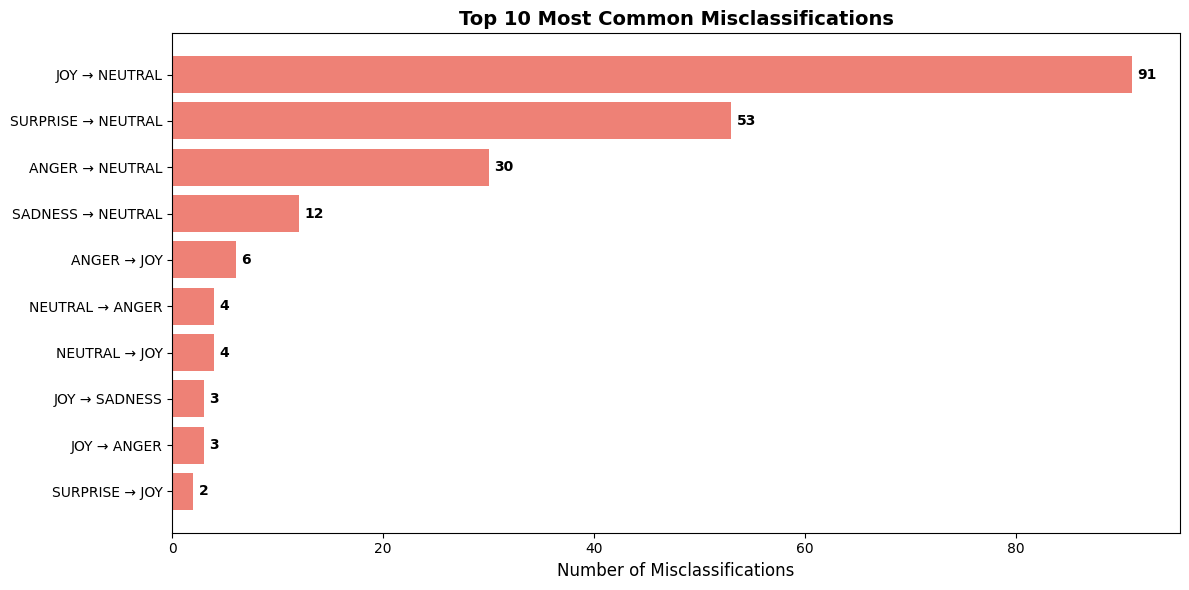


Total incorrect predictions: 221

Top 10 Misclassification Pairs:
actual_pillar model_prediction  count
          JOY          NEUTRAL     91
     SURPRISE          NEUTRAL     53
        ANGER          NEUTRAL     30
      SADNESS          NEUTRAL     12
        ANGER              JOY      6
      NEUTRAL            ANGER      4
      NEUTRAL              JOY      4
          JOY          SADNESS      3
          JOY            ANGER      3
     SURPRISE              JOY      2


In [ ]:
# 7. TOP MISCLASSIFICATIONS - Most Common Errors
df_errors = df_all[df_all['is_correct'] == 0].copy()

error_pairs = df_errors.groupby(['actual_pillar', 'model_prediction']).size().reset_index(name='count')
error_pairs = error_pairs.sort_values('count', ascending=False).head(10)

plt.figure(figsize=(12, 6))
error_pairs['pair'] = error_pairs['actual_pillar'] + ' → ' + error_pairs['model_prediction']
bars = plt.barh(error_pairs['pair'], error_pairs['count'], color='#e74c3c', alpha=0.7)
plt.xlabel('Number of Misclassifications', fontsize=12)
plt.title('Top 10 Most Common Misclassifications', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

for i, v in enumerate(error_pairs['count'].values):
    plt.text(v + 0.5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/07_top_misclassifications.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTotal incorrect predictions: {len(df_errors)}")
print(f"\nTop 10 Misclassification Pairs:")
print(error_pairs[['actual_pillar', 'model_prediction', 'count']].to_string(index=False))

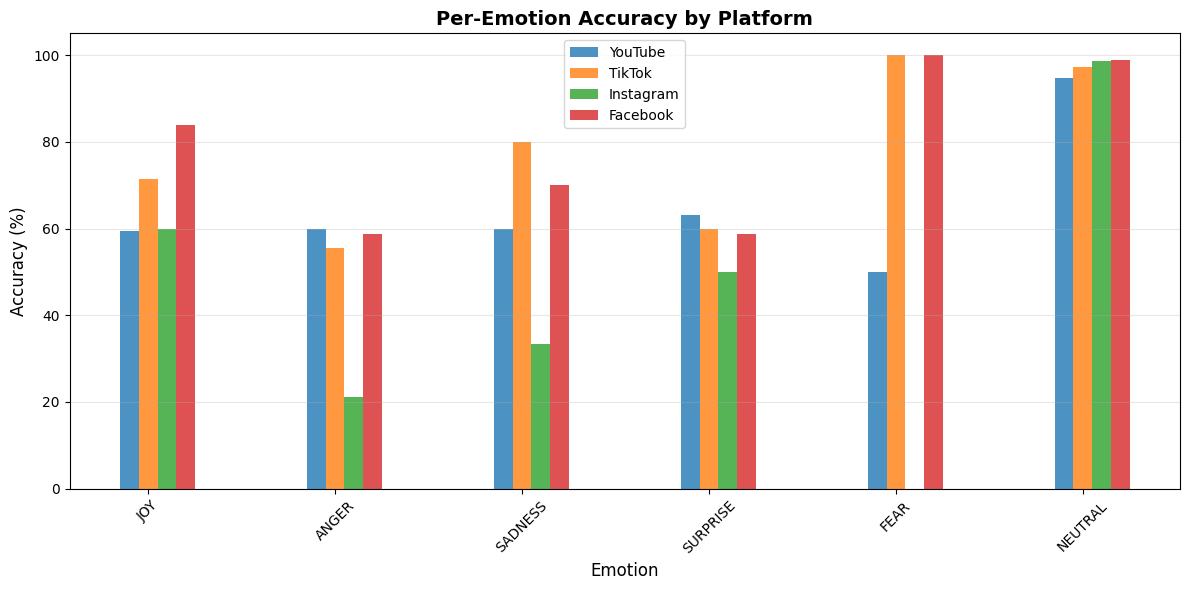


Per-Platform Per-Emotion Accuracy (%):
             JOY  ANGER  SADNESS  SURPRISE   FEAR  NEUTRAL
YouTube    59.49  60.00    60.00     63.16   50.0    94.67
TikTok     71.43  55.56    80.00     60.00  100.0    97.27
Instagram  60.00  21.05    33.33     50.00    0.0    98.63
Facebook   83.87  58.62    70.00     58.82  100.0    98.77


In [ ]:
# 8. PER-PLATFORM EMOTION ACCURACY
platform_emotion_acc_list = []
platforms_names_list = ['YouTube', 'TikTok', 'Instagram', 'Facebook']

for platform_name in platforms_names_list:
    df_platform = df_all[df_all['platform'] == platform_name]
    platform_acc = []
    for emotion in emotions:
        mask = df_platform['actual_pillar'] == emotion
        if mask.sum() > 0:
            acc = (df_platform[mask]['is_correct'].sum() / mask.sum() * 100)
            platform_acc.append(acc)
        else:
            platform_acc.append(0)
    platform_emotion_acc_list.append(platform_acc)

platform_emotion_df = pd.DataFrame(platform_emotion_acc_list, 
                                   index=platforms_names_list,
                                   columns=emotions)

plt.figure(figsize=(12, 6))
x = np.arange(len(emotions))
width = 0.1

for idx, platform_name in enumerate(platforms_names_list):
    offset = (idx - 1) * width
    plt.bar(x + offset, platform_emotion_df.iloc[idx], width, 
            label=platform_name, alpha=0.8)

plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Per-Emotion Accuracy by Platform', fontsize=14, fontweight='bold')
plt.xticks(x, emotions, rotation=45)
plt.ylim([0, 105])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/08_per_platform_emotion_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPer-Platform Per-Emotion Accuracy (%):")
print(platform_emotion_df.round(2))

In [61]:
# 9. DETAILED CLASSIFICATION REPORT
print("="*70)
print("OVERALL CLASSIFICATION REPORT (All Platforms)")
print("="*70)
print(classification_report(y_true, y_pred, labels=emotions, target_names=emotions, digits=3))

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)
print(f"Total Samples: {len(df_all)}")
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")
print(f"Macro Average F1-Score: {f1_score(y_true, y_pred, labels=emotions, average='macro')*100:.2f}%")
print(f"Weighted Average F1-Score: {f1_score(y_true, y_pred, labels=emotions, average='weighted')*100:.2f}%")

OVERALL CLASSIFICATION REPORT (All Platforms)
              precision    recall  f1-score   support

         JOY      0.940     0.689     0.795       318
       ANGER      0.826     0.494     0.618        77
     SADNESS      0.852     0.575     0.687        40
    SURPRISE      0.929     0.585     0.718       135
        FEAR      0.714     0.833     0.769         6
     NEUTRAL      0.638     0.973     0.771       339

    accuracy                          0.758       915
   macro avg      0.817     0.692     0.726       915
weighted avg      0.812     0.758     0.755       915


SUMMARY STATISTICS
Total Samples: 915
Overall Accuracy: 75.85%
Macro Average F1-Score: 72.63%
Weighted Average F1-Score: 75.49%
